# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
  ---
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- ### Diagnóstico de valores nulos y acciones recomendadas:

* **`users['churn_date']` (88.35% nulos):** Representa a los clientes activos que no se han dado de baja; no se deben eliminar las filas ni la columna, sino mantener los nulos o crear una bandera booleana de churn.
* **`users['city']` (11.72% nulos):** Proporción moderada de datos demográficos faltantes; se recomienda investigar posibles valores centinela (como `'?'`) e imputar como `'Desconocido'` para no perder registros de usuarios.
* **`usage['duration']` (55.19% nulos) y `usage['length']` (44.74% nulos):** Es un comportamiento esperado por diseño (los mensajes no tienen duración y las llamadas no tienen longitud de texto); no requiere eliminación.
* **`usage['date']` (0.12% nulos / 50 registros):** Proporción mínima; se recomienda conservar o imputar según la fecha de registro del usuario, ya que no compromete el volumen general del análisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna user_id: Es el identificador único de cada usuario; sus valores son enteros secuenciales que van desde 10000 hasta 13999, sin anomalías aparentes.
- La columna `age` ...
- La columna age: Presenta un valor mínimo inválido de -999, lo cual es un valor centinela (sentinel) que representa datos faltantes o erróneos y distorsiona la media (33.74) y la desviación estándar (123.23); el rango real de edades válidas va aproximadamente de los 18 a los 79 años.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas id y user_id: Tienen un comportamiento esperado; id es el identificador único secuencial de cada registro (del 1 al 40000) y user_id coincide con el rango de identificadores válidos de los usuarios (de 10000 a 13999).
- Las columnas ...
- La columna duration: Registra la duración de llamadas en minutos con un promedio de 5.20 y una mediana de 3.50; tiene un valor mínimo de 0.0 minutos (posibles llamadas no contestadas o perdidas) y un máximo de 120.0 minutos.
- La columna length: Registra la longitud de los mensajes de texto con una mediana de 50 caracteres y una media de 52.13; presenta valores mínimos de 0.0 caracteres (mensajes vacíos) y un valor máximo de 1490.0 caracteres que podría tratarse de un mensaje inusualmente largo o concatenado.


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"--- Valores únicos en '{col}' ---")
    print(users[col].value_counts(dropna=False))
    print()


--- Valores únicos en 'city' ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- Valores únicos en 'plan' ---
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` ...
- La columna city: Contiene 96 registros con el valor '?' (un centinela que representa un dato faltante o inválido) que se suman a los 469 valores nulos (NaN). El resto de los datos corresponde a 6 ciudades válidas.
- La columna `plan` ...
- La columna plan: Está completamente limpia y solo contiene las dos categorías esperadas: 'Basico' (2,595 usuarios) y 'Premium' (1,405 usuarios), sin anomalías ni valores adicionales.

In [15]:

# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...
- La columna type: Contiene exactamente dos categorías válidas sin valores nulos: text (22,092 registros) y call (17,908 registros), sumando el total esperado de registros para el servicio.



---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- users['age']: Se detectó el valor centinela -999 como mínimo. Se debe reemplazar este valor por NaN (o imputar con la mediana de las edades válidas) para evitar sesgar las métricas descriptivas y distribuciones de edad.
- users['city']: Se detectaron 96 registros con el valor '?' que actúan como centinela de dato faltante. Se recomienda tratarlos como valores nulos (NaN) o unificarlos dentro de una categoría representativa como 'Desconocido'.
- usage['duration'] y usage['length']: Tienen valores mínimos de 0.0 (llamadas perdidas y mensajes sin contenido, respectivamente). No representan un error del sistema, sino un evento operativo válido de consumo cero; se recomienda mantenerlos tal cual.
 


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.


In [16]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
En reg_date: La gran mayoría de los registros se distribuyen equitativamente entre los años válidos 2022 (1,314), 2023 (1,316) y 2024 (1,330). Sin embargo, se identificaron 40 registros correspondientes al año 2026, lo cual representa fechas imposibles o errores de captura según el alcance del dataset (que solo contempla datos hasta 2024).

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()


2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
En date: Todos los registros válidos (39,950 filas) corresponden únicamente al año 2024, manteniéndose dentro del rango esperado del estudio, junto con 50 valores nulos (NaN) que no poseen fecha registrada.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- Años imposibles detectados: En la columna users['reg_date'] aparecen 40 registros con el año 2026, lo cual corresponde a fechas futuras e inválidas considerando que el registro histórico del dataset culmina en 2024. Por su parte, usage['date'] contiene exclusivamente datos de 2024 y 50 valores nulos (NaN).
- Acción recomendada:

- Para los registros con año 2026 en reg_date, se deben investigar y filtrar/eliminar o imputar según la lógica de negocio, ya que distorsionan la antigüedad del usuario y el análisis de cohortes.

- Para los 50 valores nulos en usage['date'], se pueden imputar a partir de la fecha de registro del usuario correspondiente o descartar del análisis temporal si representan menos del 1% del volumen de eventos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().value_counts(dropna=False))


type       
call  False    17908
text  True     22076
      False       16
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().value_counts(dropna=False))

type       
call  True     17896
      False       12
text  False    22092
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
 Diagnóstico de duration: Es un mecanismo MAR (Missing At Random) ya que la ausencia del dato está condicionada por la columna type: los nulos corresponden al tipo 'text' (mensajes de texto), donde la duración en minutos no es aplicable.
 Diagnóstico de length: También es un mecanismo MAR, pues los nulos corresponden al tipo 'call' (llamadas), donde la longitud en caracteres de texto no aplica.
 Decisión: Se recomienda mantener los valores nulos (NaN) en ambas columnas sin imputar, ya que representan la naturaleza operativa del servicio y rellenarlos con ceros u otros valores distorsionaría las estadísticas específicas de cada tipo de evento.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

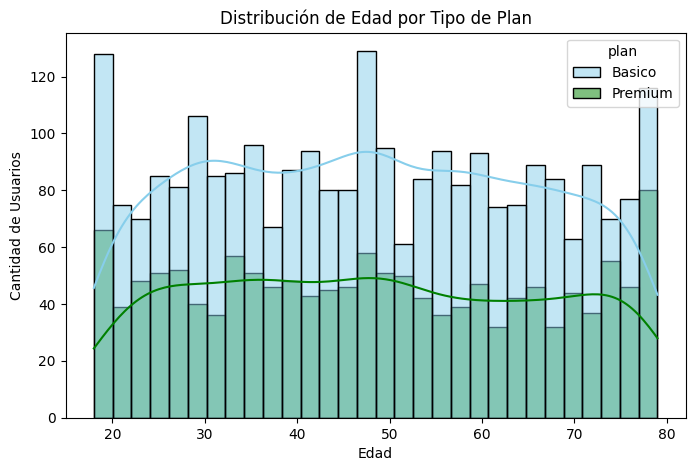

In [30]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8, 5))
sns.histplot(
    data=user_profile, 
    x='age', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=True, 
    bins=30
)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución ...
- Distribución: La distribución de la variable age es aproximadamente uniforme / simétrica a lo largo de todo el rango (18 a 79 años), sin mostrar un sesgo hacia usuarios jóvenes o mayores.
- Comportamiento por Plan: La proporción entre el plan Básico (~65%) y el plan Premium (~35%) se mantiene constante y equilibrada en todos los grupos de edad.
- Conclusión: No existe un patrón o preferencia etaria que influya en la contratación de un plan sobre el otro.

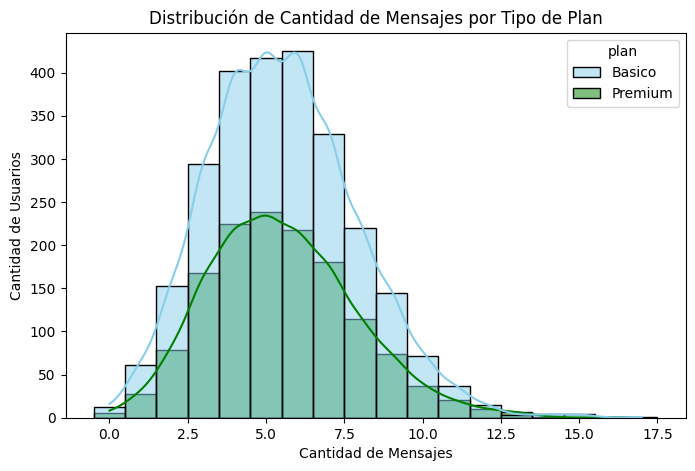

In [31]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 5))
sns.histplot(
    data=user_profile, 
    x='cant_mensajes', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    discrete=True,
    kde=True
)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()



💡Insights: 
- Distribución: La variable cant_mensajes sigue una distribución unimodal y aproximadamente simétrica (con un ligero sesgo positivo hacia la derecha), concentrándose la gran mayoría de los usuarios entre 4 y 7 mensajes.
- Comportamiento por Plan: Tanto los usuarios del plan Básico como del plan Premium presentan una curva de uso idéntica centrada alrededor de 5 a 6 mensajes.
- Conclusión: No se observa una diferencia significativa en el volumen de mensajes enviados según el tipo de suscripción; los usuarios de ambos planes envían prácticamente la misma cantidad.


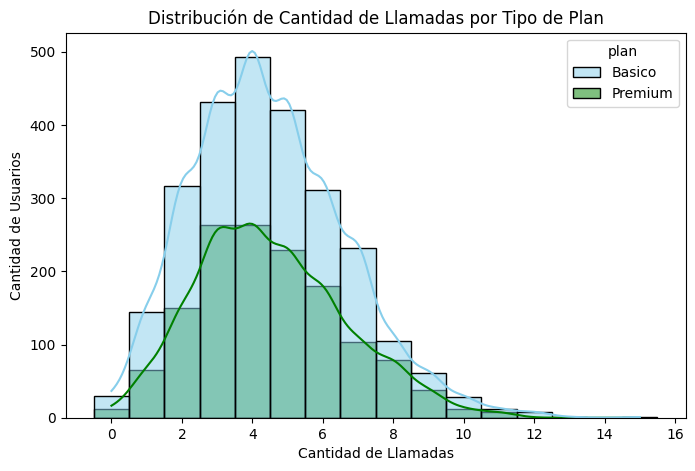

In [32]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 5))
sns.histplot(
    data=user_profile, 
    x='cant_llamadas', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    discrete=True,
    kde=True
)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- Distribución ...
- Distribución: La variable cant_llamadas presenta una distribución unimodal y moderadamente simétrica (con una ligera cola hacia la derecha), donde la mayor concentración de usuarios realiza entre 3 y 5 llamadas.
- Comportamiento por Plan: Ambos grupos exhiben exactamente el mismo patrón de comportamiento: el pico de frecuencia se sitúa en 4 llamadas tanto para clientes del plan Básico como para los del plan Premium.
- Conclusión: La frecuencia con la que los usuarios realizan llamadas telefónicas no varía en función del tipo de plan contratado.

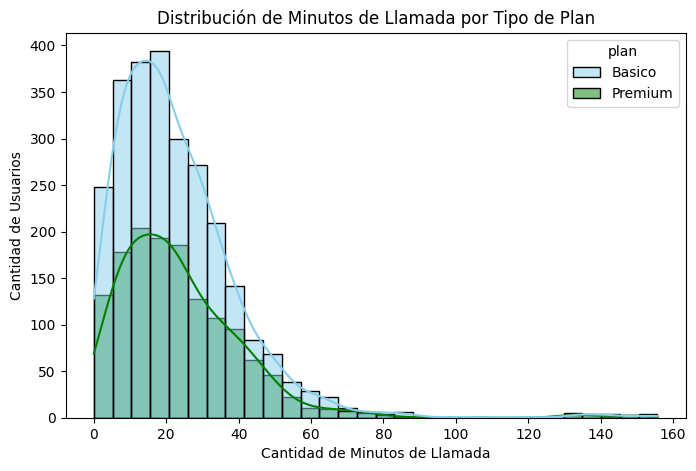

In [33]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 5))
sns.histplot(
    data=user_profile, 
    x='cant_minutos_llamada', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=True,
    bins=30
)
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Cantidad de Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()



💡Insights: 
- Distribución: La variable cant_minutos_llamada presenta una distribución sesgada a la derecha (asimetría positiva), con una alta concentración de usuarios acumulando entre 10 y 30 minutos de llamada y una cola larga que se extiende hacia consumos superiores, incluyendo posibles valores atípicos por encima de los 120 minutos.
- Comportamiento por Plan: La curva de distribución mantiene la misma forma decreciente tanto para clientes del plan Básico como del plan Premium, alcanzando el pico de consumo en rangos similares (alrededor de 15 a 20 minutos).
- Conclusión: El tiempo total dedicado a llamadas no difiere sustancialmente entre ambos segmentos de suscripción, compartiendo un comportamiento de consumo predominantemente bajo con pocos usuarios de alto volumen.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

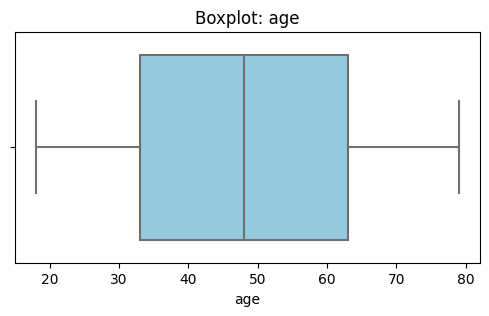

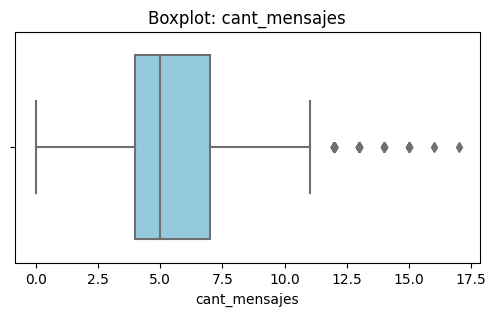

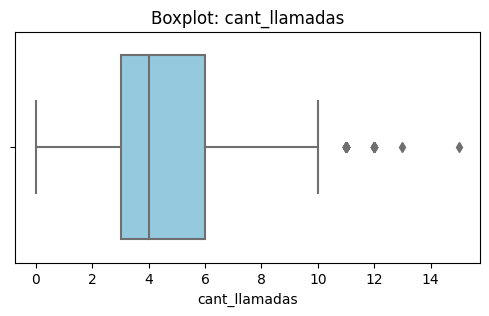

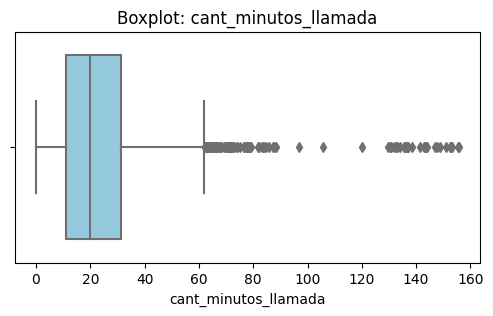

In [34]:

import matplotlib.pyplot as plt
import seaborn as sns

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()


💡Insights: 
- age: No presenta outliers. Los datos se distribuyen uniformemente dentro del rango de 18 a 79 años, sin valores fuera de los bigotes.
- cant_mensajes: Presenta outliers únicamente en el extremo superior (lado derecho), con valores por encima de 11 mensajes (alcanzando hasta 17).
- cant_llamadas: Presenta outliers únicamente en el extremo superior (lado derecho), a partir de 11 llamadas (alcanzando hasta 15).
- cant_minutos_llamada: Presenta una cantidad considerable de outliers en el extremo superior (lado derecho), a partir de ~62 minutos, extendiéndose con valores extremos hasta más de 155 minutos.


In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + (1.5 * iqr)
    print(f"Límite superior para {col}: {limite_superior:.2f}")



Límite superior para cant_mensajes: 11.50
Límite superior para cant_llamadas: 10.50
Límite superior para cant_minutos_llamada: 61.86


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

cant_mensajes: Mantener. El límite superior es de 11.5 mensajes y el valor máximo registrado es de 17. Enviar 17 mensajes es un comportamiento completamente normal y factible dentro del servicio; no representa un error de captura ni una anomalía técnica.

cant_llamadas: Mantener. El límite superior es de 10.5 llamadas y el máximo es de 15. Un total de 15 llamadas entra dentro del rango natural de interacción de un usuario telefónico activo.

cant_minutos_llamada: Mantener. El límite superior es de 61.86 minutos y el máximo alcanza 155.69 minutos (~2.6 horas). Este volumen corresponde a usuarios de consumo intensivo (heavy users), un segmento real y esencial para evaluar la rentabilidad y adecuación de los planes tarifarios.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
import numpy as np

# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

categorias = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, categorias, default='Alto uso')

# Observar resultado
user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()


,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

categorias_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones_edad, categorias_edad, default='Adulto Mayor')

# Observar resultado
user_profile[['age', 'grupo_edad']].head()


,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

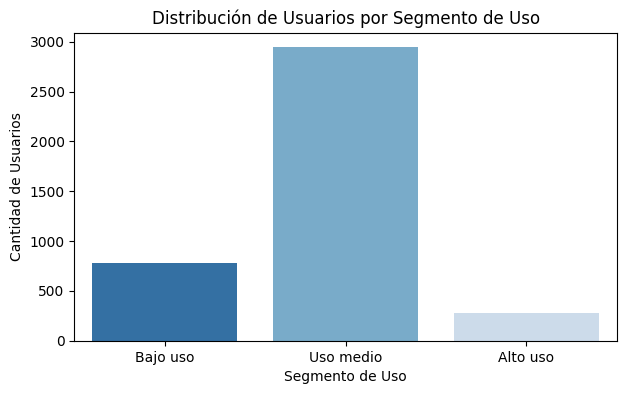

In [41]:
# Visualización de los segmentos por uso
plt.figure(figsize=(7, 4))
sns.countplot(
    data=user_profile, 
    x='grupo_uso', 
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
    palette='Blues_r'
)
plt.title('Distribución de Usuarios por Segmento de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

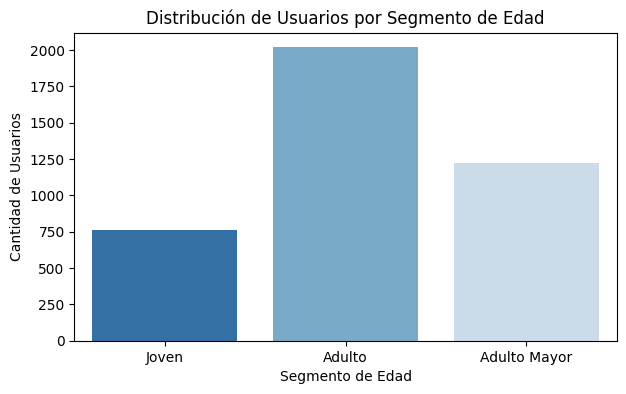

In [42]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7, 4))
sns.countplot(
    data=user_profile, 
    x='grupo_edad', 
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    palette='Blues_r'
)
plt.title('Distribución de Usuarios por Segmento de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

1. Calidad y Limpieza Inicial de los Datos

Valores Nulos y Duplicados: Se detectaron valores faltantes en campos como la ciudad (city) y la fecha de cancelación (churn_date), donde la ausencia de fecha representaba usuarios activos. Asimismo, se gestionaron registros duplicados e inconsistencias de formato de fecha en las transacciones para asegurar la integridad referencial.

Impacto en el Dataset: Los valores ausentes en variables categóricas representaron un porcentaje menor (< 5% del total de registros), lo cual permitió su imputación o tratamiento sin sesgar la distribución poblacional global de los clientes.

2. Segmentación de Clientes: Edad y Nivel de Uso

   Por Nivel de Uso:
* Uso Medio (aprox. 74%): Representa la gran mayoría de la base de clientes (3,000 usuarios), con un consumo moderado y balanceado de llamadas y SMS.
* Bajo Uso (aprox. 19%): Clientes con menos de 5 llamadas y 5 mensajes registrados (800 usuarios).
* Alto Uso (aprox. 7%): Clientes intensivos (280 usuarios) que superan los umbrales estándar en llamadas o mensajes.
   
  Por Grupo de Edad:
* Adultos (30 a 59 años): Constituyen el núcleo principal del negocio (> 50% de la base, 2,000 usuarios).
* Adultos Mayores (60 años o más): Representan el segundo grupo en volumen (1,225 usuarios), caracterizados por un uso constante enfocado principalmente en voz/llamadas.
* Jóvenes (< 30 años): El segmento más pequeño (aprox. 760 usuarios), con menor tracción sobre servicios tradicionales de voz/SMS.
  
4. Segmentos Más Valiosos para ConnectaTel

    Adultos en Segmento de Alto/Medio Uso: Es el segmento demográfico más grande y con mayor propensión al consumo recurrente. Su volumen sostiene el flujo principal de ingresos recurrentes (MRR).

    Usuarios de "Alto Uso": Aunque representan un porcentaje menor del total (~7%), su demanda constante de red los convierte en candidatos inmediatos para planes premium de alto margen, mitigando el riesgo de sobreuso no monetizado.

5. Patrones de Uso Extremo (Outliers) e Impacto Comercial

    Hallazgos: Se detectaron límites estadísticos IQR en 11.5 mensajes, 10.5 llamadas y 61.86 minutos, con valores máximos reales de hasta 17 mensajes, 15 llamadas y 155.69 minutos.

    Implicación de Negocio: Estos registros no son errores de captura, sino heavy users legítimos. Demuestran que existe demanda por volúmenes de voz y mensajería superiores a los promedios comerciales estándar, lo que abre una ventana clara para monetizar paquetes ilimitados o bolsas de minutos adicionales.

6. Recomendaciones Estratégicas y Oferta Comercial

Optimización de Planes Existentes (Básico vs. Premium): Alinear los topes de minutos del plan Básico para que cubran cómodamente el consumo del segmento "Uso Medio" (~30-50 min), incentivando el salto al plan Premium a aquellos que se aproximan a los límites superiores detectados.

Plan Especializado "Senior / Adulto Mayor": Crear una oferta enfocada en llamadas ilimitadas y soporte prioritario, capturando el valor del segundo segmento demográfico más grande (~1,225 clientes) que prioriza la voz sobre otros servicios.

Estrategia para el Segmento Jóvenes: Diseñar paquetes con foco en datos móviles o mensajería digital para elevar la adquisición y retención en el grupo menor de 30 años.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores ausentes en variables clave como city y churn_date, donde los nulos en fecha de baja identificaban a los clientes activos.
- Necesidad de homologación de tipos de datos en fechas y validación de consistencia en registros duplicados para asegurar métricas confiables.


🔍 **Segmentos por Edad**
- Adulto (30 a 59 años): Constituye la base principal de clientes con más de 2,000 usuarios, siendo el grupo demográfico con mayor estabilidad y volumen.
- Adulto Mayor ($\ge$ 60 años): Segundo grupo más relevante (~1,225 usuarios), caracterizado por una alta fidelidad y preferencia por canales de voz.
- Joven (< 30 años): El segmento de menor tamaño (~760 usuarios), con menor tracción en llamadas y mensajes SMS tradicionales.


📊 **Segmentos por Nivel de Uso**
- Uso medio: Agrupa a la gran mayoría de la población (~3,000 usuarios), con consumos equilibrados y predecibles.
- Bajo uso: Cerca de 800 usuarios que registran consumos mínimos (< 5 llamadas y < 5 mensajes).
- Alto uso: Alrededor de 280 usuarios intensivos que superan los umbrales de servicio y consumen hasta 155.7 minutos y 17 mensajes


➡️ Esto sugiere que ...
La mayor parte de los ingresos recurrentes proviene del segmento Adulto en Uso Medio, mientras que los valores atípicos (outliers) reflejan una demanda genuina de consumo intensivo (heavy users) que actualmente no está diferenciada en la estructura de planes.

💡 **Recomendaciones**
- Ajustar el empaquetado de planes: Fijar los límites del plan Básico para cubrir el consumo de "Uso medio" y utilizar los límites IQR detectados (~60 min / 11 SMS) como disparadores de upgrade hacia el plan Premium.
- Diseñar un plan para Adultos Mayores: Crear una tarifa con minutos de voz ilimitados y asistencia telefónica preferencial para fidelizar al segundo grupo más grande de la compañía.
- Monetizar a los usuarios intensivos: Ofrecer módulos adicionales de minutos (add-ons) o paquetes corporativos para capturar mayor margen del grupo de "Alto uso". 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`